In [17]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm=ChatGroq(model="qwen-2.5-32b")

In [18]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Graph states
class State(TypedDict):
    task : str
    reviewer : str
    manager : str

In [19]:
# Nodes

def generate_code(state: State):
    """First LLM call to generate code for the given input task"""

    msg = llm.invoke(f"Write a python code for solving the problem {state['task']}")
    
    return {'reviewer' : msg.content}

def review(state: State):
    """Review the generated code with detailed feedback"""
    
    prompt = f"""
    Review the following Python code:
    {state['reviewer']}
    
    Look for:
    - Syntax errors
    - Logical errors
    - Best practices
    - Code efficiency

    Provide a structured review with a summary of issues and a final verdict:
    - 'Code is perfect' if no issues.
    - 'Code needs improvement' if issues exist.
    """
    
    msg = llm.invoke(prompt)
    return {'manager': msg}

def check_code(state: State):
    """Function to check if the code is perfect or needs improvement"""

    if state['reviewer'] == 'Code needs improvement':
        return 'Fail'
    return 'Pass'
 
def document(state: State):
    """Third LLM call so that the code can be documented"""
    
    msg = llm.invoke(f"Document the code for {state['task']}")

    return {'manager' : msg.content}


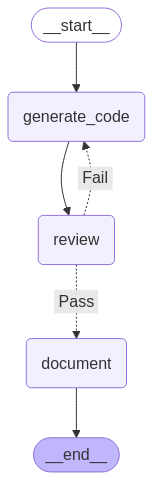

In [20]:
# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_code", generate_code)
workflow.add_node("review", review)
workflow.add_node("document", document)

# Add edges to connect nodes
workflow.add_edge(START, "generate_code")
workflow.add_edge("generate_code", "review")
workflow.add_conditional_edges("review",check_code,{'Pass':'document','Fail':'generate_code'})
workflow.add_edge("document", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

In [21]:
state = chain.invoke({'task': 'Write a function to add two numbers'})

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

In [ ]:
state

{'task': 'Write a function to add two numbers',
 'reviewer': 'Certainly! Below is a simple Python function that takes two numbers as input and returns their sum.\n\n```python\ndef add_two_numbers(a, b):\n    """\n    Add two numbers and return the sum.\n\n    Parameters:\n    a (int, float): The first number.\n    b (int, float): The second number.\n\n    Returns:\n    int, float: The sum of the two numbers.\n    """\n    return a + b\n\n# Example usage:\n# result = add_two_numbers(3, 5)\n# print("The sum is:", result)\n```\n\nThis function, `add_two_numbers`, takes two parameters `a` and `b`, which can be either integers or floating-point numbers, and returns their sum. You can call this function with any two numbers to get their sum. The commented lines at the end show how you can use this function to add two numbers (3 and 5 in this case) and print the result.',
 'manager': 'Certainly! Below is an example of how you can document a simple function that adds two numbers. The documenta

In [ ]:
state['task']

'Write a function to add two numbers'

In [ ]:
state['reviewer']

'Certainly! Below is a simple Python function that takes two numbers as input and returns their sum.\n\n```python\ndef add_two_numbers(a, b):\n    """\n    Add two numbers and return the sum.\n\n    Parameters:\n    a (int, float): The first number.\n    b (int, float): The second number.\n\n    Returns:\n    int, float: The sum of the two numbers.\n    """\n    return a + b\n\n# Example usage:\n# result = add_two_numbers(3, 5)\n# print("The sum is:", result)\n```\n\nThis function, `add_two_numbers`, takes two parameters `a` and `b`, which can be either integers or floating-point numbers, and returns their sum. You can call this function with any two numbers to get their sum. The commented lines at the end show how you can use this function to add two numbers (3 and 5 in this case) and print the result.'

In [ ]:
state['manager'].astype

NameError: name 'state' is not defined